In [44]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
suppressMessages(library(tidyr))
suppressMessages(library(foreach))
suppressMessages(library(doParallel))
suppressMessages(library(tidygraph))
suppressMessages(library(anndata))
suppressMessages(library(randomForest))
suppressMessages(library(pheatmap))
suppressMessages(library(dbscan))
suppressMessages(library(scDblFinder))
suppressMessages(library(cowplot))

# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)


In [45]:
seurat = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260728_VTA_SCTseurat_harmony_rf_clean.rds')

In [46]:
neuron = subset(seurat, Class == 'Neuron' & nFeature_RNA > 800)
neuron

An object of class Seurat 
39743 features across 8882 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony converged after 2 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declari

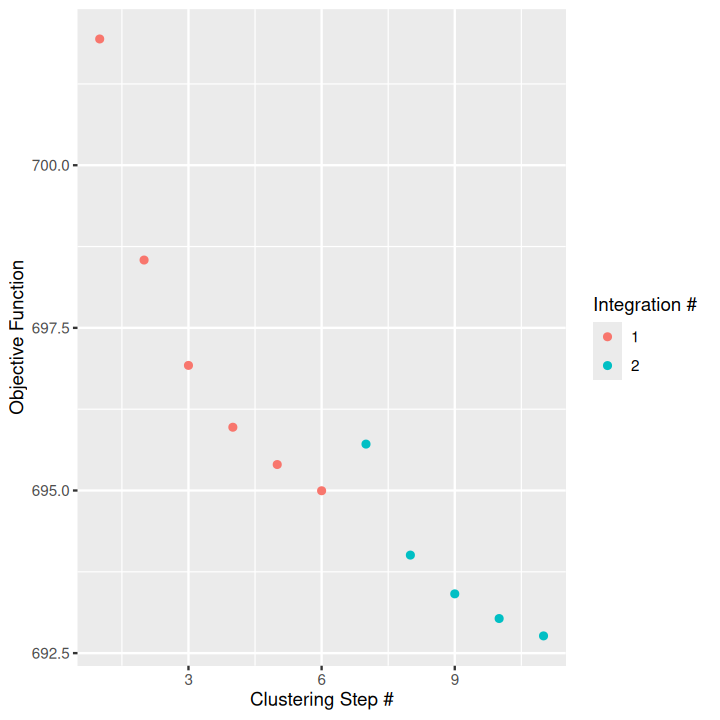

In [47]:
class_resolution = 0.5

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

assay = neuron@assays$RNA$counts
meta = neuron@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

neuron_1 = CreateSeuratObject(counts = new_assay)
neuron_1 = AddMetaData(neuron_1, meta)

neuron_1 = NormalizeData(neuron_1, normalization.method = "LogNormalize", scale.factor = 10000)
neuron_1 = FindVariableFeatures(neuron_1, selection.method = "vst", nfeatures = 3000)
neuron_1 = ScaleData(neuron_1, features = rownames(neuron_1))

neuron_1 = neuron_1 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

neuron_1 = RunHarmony(
    neuron_1, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

neuron_1 = neuron_1 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

### Neuron clustering

In [48]:
neuron_2 = neuron_1
df1 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/IP-VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)
df2 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)

# 按照 index (细胞名/行名) 顺序添加
mouse_anno = c(df1$class_name, df2$class_name)
names(mouse_anno) = c(rownames(df1), rownames(df2))
# 只添加有 index 匹配的，用对象的 cell 名做索引
matched_anno = mouse_anno[colnames(neuron_2)]
neuron_2$Mouse_anno = matched_anno

In [49]:
table(neuron_2$Mouse_anno, neuron_2$seurat_clusters)


                   
                      0   1   2   3   4   5   6   7   8   9  10  11  12  13  14
  01 IT-ET Glut       0   0   0   0   0   0   0   0   0   0   0   0   0   0   1
  02 NP-CT-L6b Glut   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  06 CTX-CGE GABA     3   6   0   0   0   0   0   0   0   0   0   0   0   0   1
  07 CTX-MGE GABA     1   5   0   0   0   0   0   0   0   0   0   0   0   0   0
  08 CNU-MGE GABA     0  18   0   0   0   0   0   0   0   0   0   0   0   0   0
  09 CNU-LGE GABA     1   0   0   0   0   0   0   0   0   0   0   1   0   0   0
  11 CNU-HYa GABA    13  18   3  11   1   1   2   0   0   0   1   0   0   0   0
  12 HY GABA         18 195   0   0   0   0   1   0   0   1   0   1   0   0   1
  13 CNU-HYa Glut    27   0   9   0   0   3   0   0   2   0   0   2   0   6   3
  14 HY Glut        423  11 301  14   6 305 185  34 161 125   0 236   0  76  29
  18 TH Glut          0   1   0   0   0   0   0   0   0   0   0   0   0   0   0
  19 MB Glut        

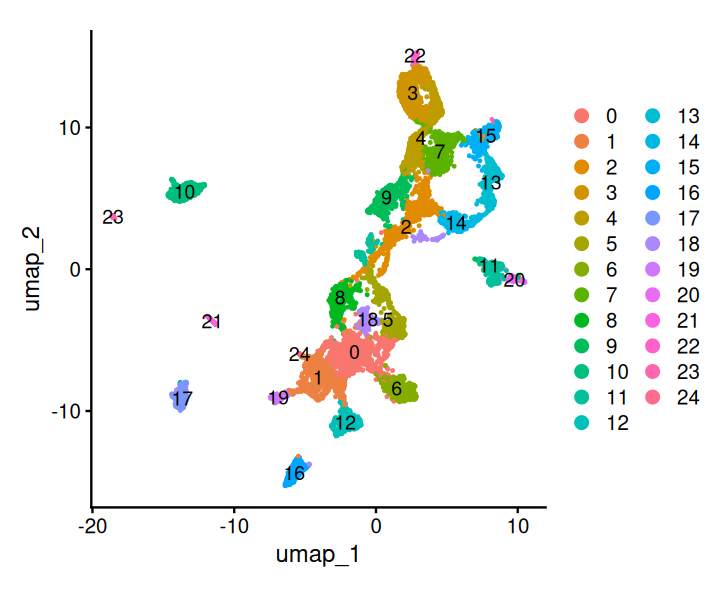

In [50]:
options(repr.plot.width=6, repr.plot.height=5)
Idents(neuron_2) <- 'seurat_clusters'
DimPlot(neuron_2, reduction="umap", label=T,raster=FALSE)+coord_fixed()

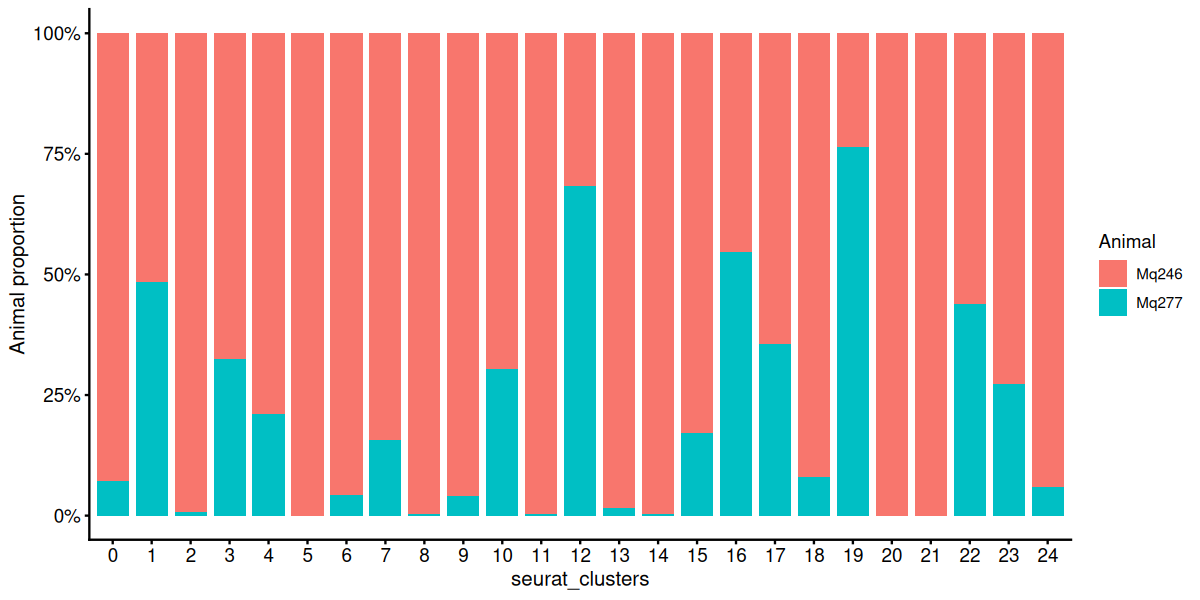

In [52]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- neuron_2@meta.data %>%
    as.data.frame() %>%
    dplyr::count(seurat_clusters, Animal) %>%
    dplyr::group_by(seurat_clusters) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=10, repr.plot.height=5)
ggplot(cluster_animal_df, aes(x = factor(seurat_clusters), y = proportion, fill = Animal)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "seurat_clusters", y = "Animal proportion", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

In [55]:
neuron_3 = subset(neuron_2, !(seurat_clusters %in% c(2,5,8,9,11,13,14,20,21)))
neuron_3

An object of class Seurat 
20344 features across 5675 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

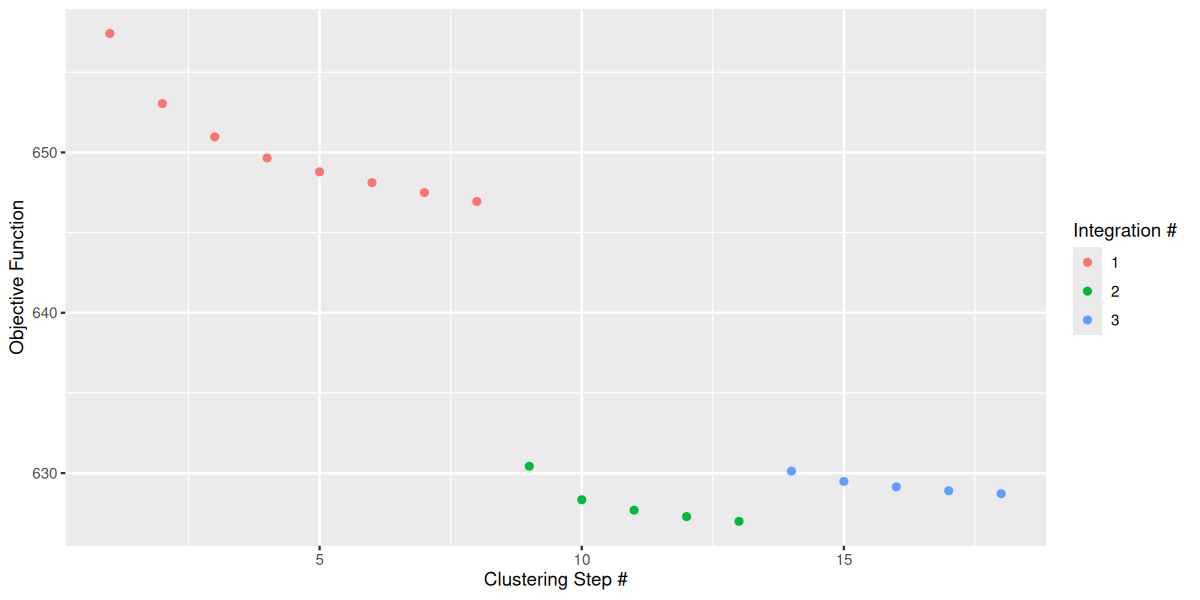

In [56]:
class_resolution = 0.3

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")
neuron_4 = neuron_3

assay = neuron_4@assays$RNA$counts
meta = neuron_4@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

neuron_4 = CreateSeuratObject(counts = new_assay)
neuron_4 = AddMetaData(neuron_4, meta)

neuron_4 = NormalizeData(neuron_4, normalization.method = "LogNormalize", scale.factor = 10000)
neuron_4 = FindVariableFeatures(neuron_4, selection.method = "vst", nfeatures = 3000)
neuron_4 = ScaleData(neuron_4, features = rownames(neuron_4))

neuron_4 = neuron_4 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

neuron_4 = RunHarmony(
    neuron_4, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

neuron_4 = neuron_4 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

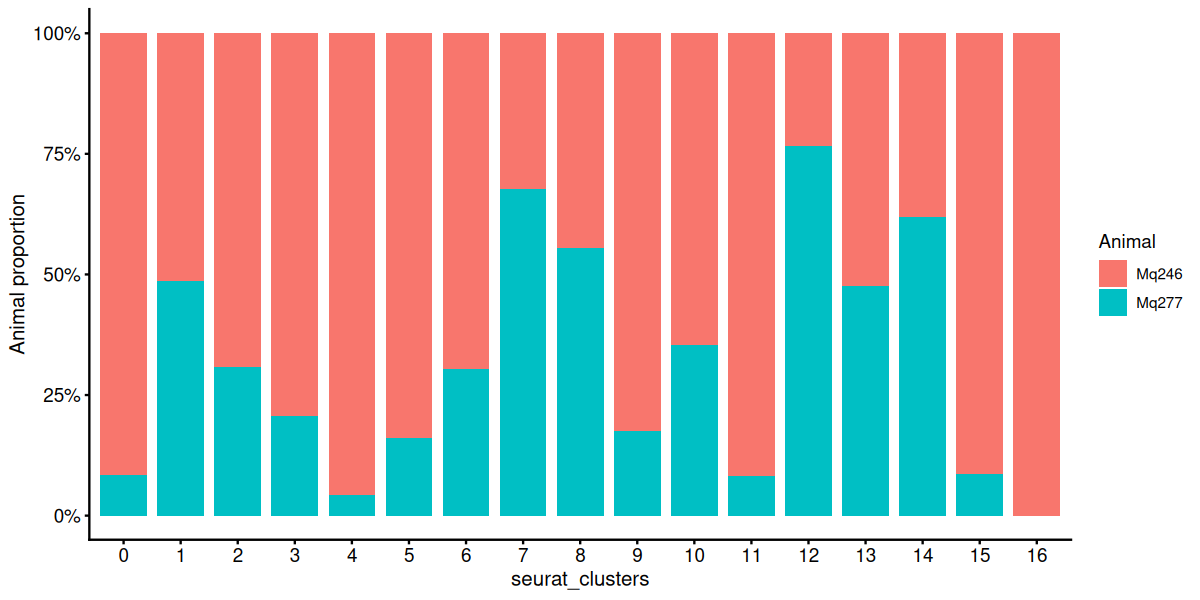

In [57]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- neuron_4@meta.data %>%
    as.data.frame() %>%
    dplyr::count(seurat_clusters, Animal) %>%
    dplyr::group_by(seurat_clusters) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=10, repr.plot.height=5)
ggplot(cluster_animal_df, aes(x = factor(seurat_clusters), y = proportion, fill = Animal)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "seurat_clusters", y = "Animal proportion", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

In [17]:
table(neuron_4$Mouse_anno, neuron_4$seurat_clusters)

                 
                    0   1   2   3   4   5   6   7   8   9  10  11  12  13  14
  06 CTX-CGE GABA   3   6   0   0   0   0   0   0   0   0   0   0   0   0   0
  07 CTX-MGE GABA   0   6   0   0   0   0   0   0   0   0   0   0   0   0   0
  08 CNU-MGE GABA   1  17   0   0   0   0   0   0   0   0   0   0   0   1   0
  09 CNU-LGE GABA   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  11 CNU-HYa GABA  13  18  11   0   2   0   1   0   0   0   1   1   0   0  19
  12 HY GABA       18 195   0   0   1   0   0   0   0   0   0   6   0   0   0
  13 CNU-HYa Glut  26   1   0   0   0   0   0   0   0   0   1   0   4   0   0
  14 HY Glut      467  14  12   8 182  33   0   0   4   0   1  50  41   0   2
  18 TH Glut        0   1   0   0   0   0   0   0   0   0   0   0   0   0   0
  19 MB Glut      312  78 163 363 237 321   0   0 180   0  35 105  86   1  17
  20 MB GABA       48 320  18  20   3   5 357 340   0 281  29  16   2 110   2
  21 MB Dopa        2   0 334  73   3  48   0 

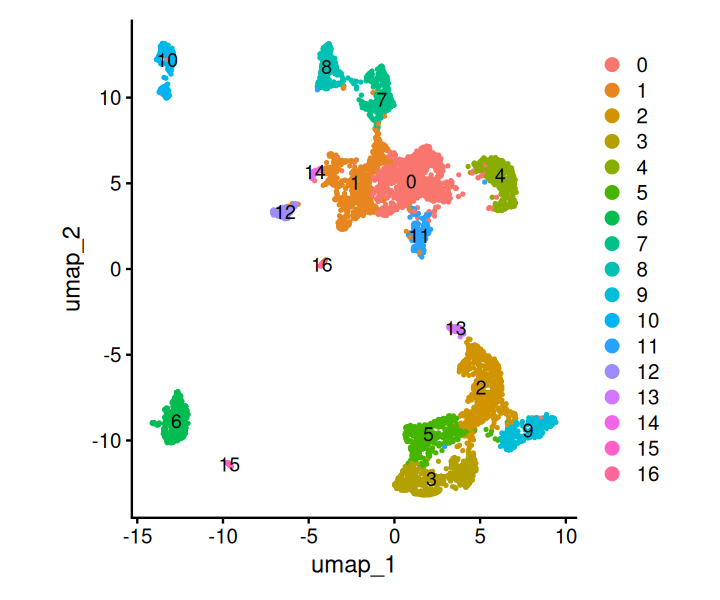

In [58]:
options(repr.plot.width=6, repr.plot.height=5)
Idents(neuron_4) <- 'seurat_clusters'
DimPlot(neuron_4, reduction="umap", label=T,raster=FALSE)+coord_fixed()

In [216]:
neuron_5 = subset(neuron_4, !(seurat_clusters %in% c(16)))
neuron_5

An object of class Seurat 
20344 features across 5655 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

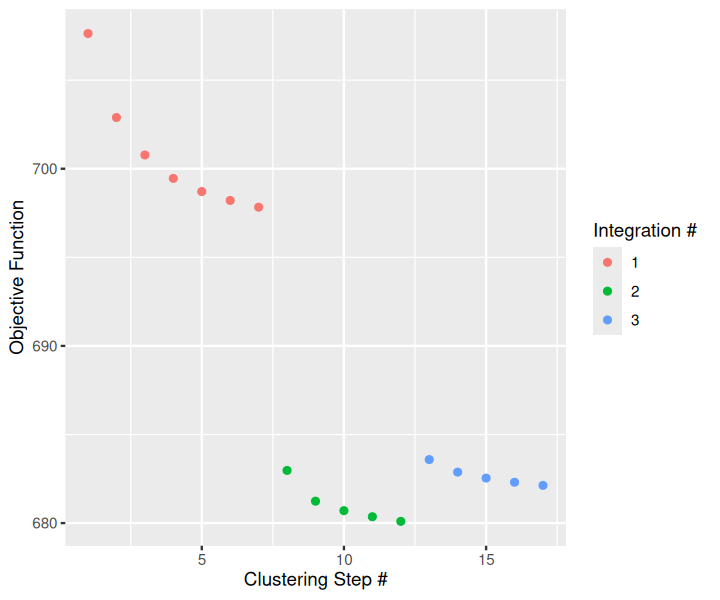

In [247]:
class_resolution = 0.3

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

assay = neuron_5@assays$RNA$counts
meta = neuron_5@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

neuron_6 = CreateSeuratObject(counts = new_assay)
neuron_6 = AddMetaData(neuron_6, meta)

neuron_6 = NormalizeData(neuron_6, normalization.method = "LogNormalize", scale.factor = 10000)
neuron_6 = FindVariableFeatures(neuron_6, selection.method = "vst", nfeatures = 3000)
neuron_6 = ScaleData(neuron_6, features = rownames(neuron_6))

neuron_6 = neuron_6 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:30) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:30, umap.method = "umap-learn")

neuron_6 = RunHarmony(
    neuron_6, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:30,
    theta = 2
)

neuron_6 = neuron_6 %>%
    FindNeighbors(reduction = "harmony", dims = 1:30) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:30)

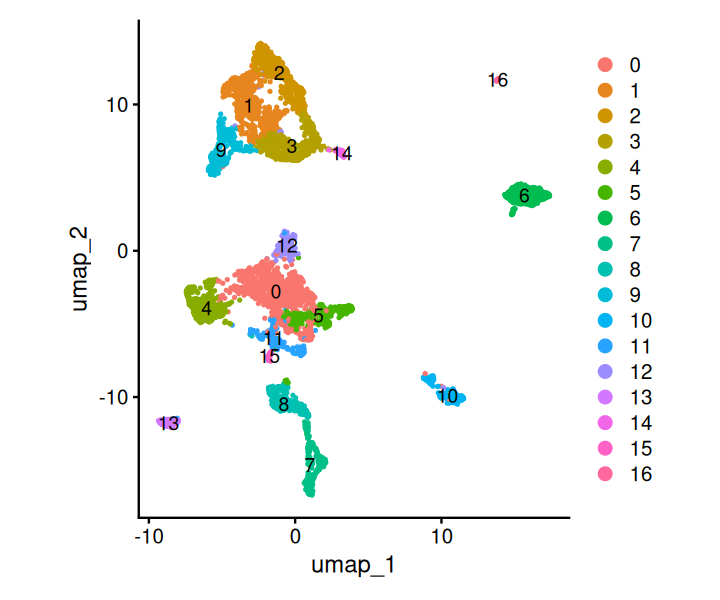

In [424]:
options(repr.plot.width=6, repr.plot.height=5)
Idents(neuron_6) <- 'seurat_clusters'
DimPlot(neuron_6, reduction="umap", label=T,raster=FALSE)+coord_fixed()

In [ ]:
neuron_6$cluster = paste0("Neuron_", neuron_6$seurat_clusters)
table(neuron_6$cluster)

In [ ]:
neuron_7 = neuron_6

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


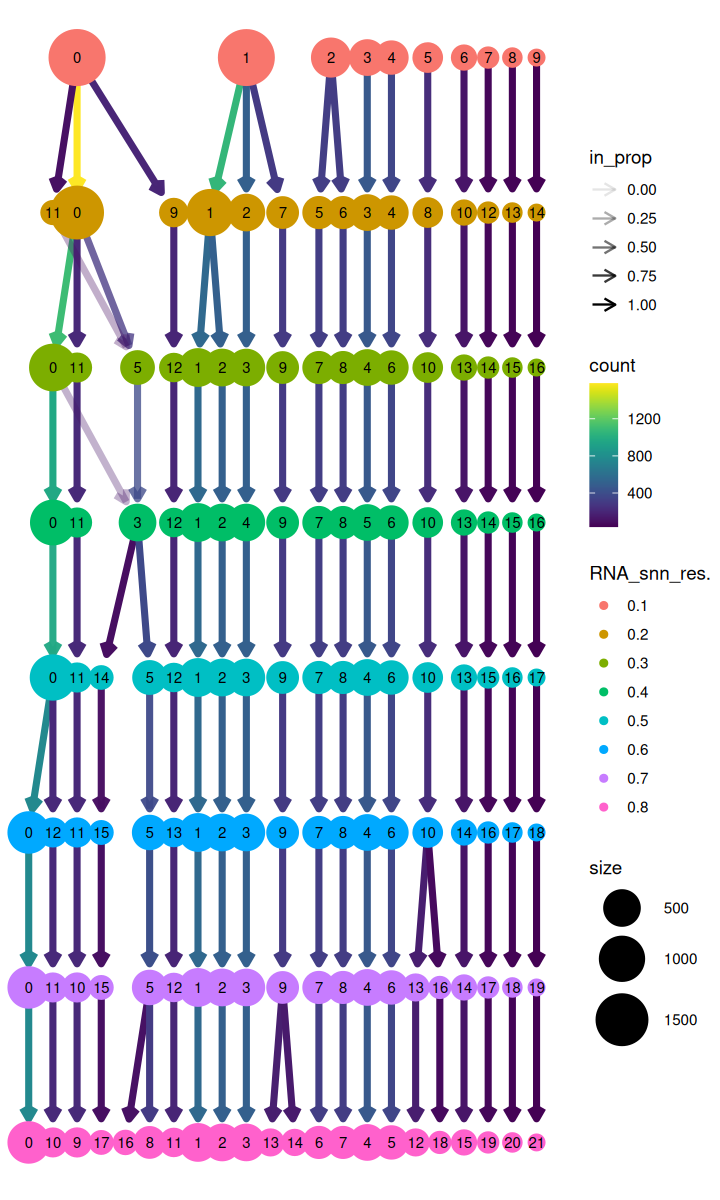

In [328]:
resolutions <- seq(0.1, 0.8, by = 0.1)

for (resolution in resolutions) {
    cluster_column <- sprintf("RNA_snn_res.%.1f", resolution)

    neuron_7 <- FindClusters(
        object = neuron_7,
        graph.name = "RNA_snn",
        resolution = resolution,
        cluster.name = cluster_column,
        random.seed = 1234,
        verbose = FALSE
    )
}

options(repr.plot.width = 6, repr.plot.height = 10)

clustree::clustree(
    neuron_7@meta.data,
    prefix = "RNA_snn_res.",
    layout = "sugiyama"
)

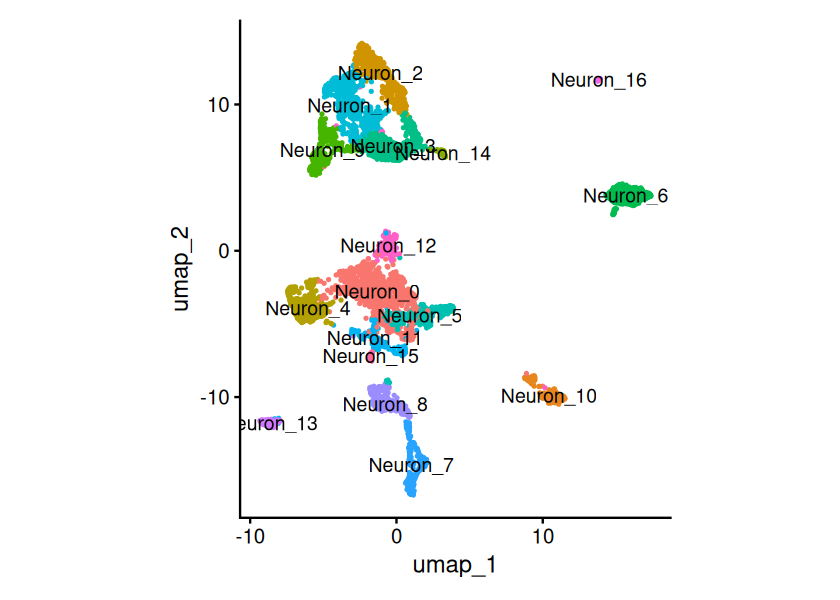

In [310]:
options(repr.plot.width = 7, repr.plot.height = 5)
Idents(neuron_7) <- "cluster"

DimPlot(neuron_7, reduction = "umap", label = TRUE, raster = FALSE) +
    coord_fixed() +
    NoLegend()

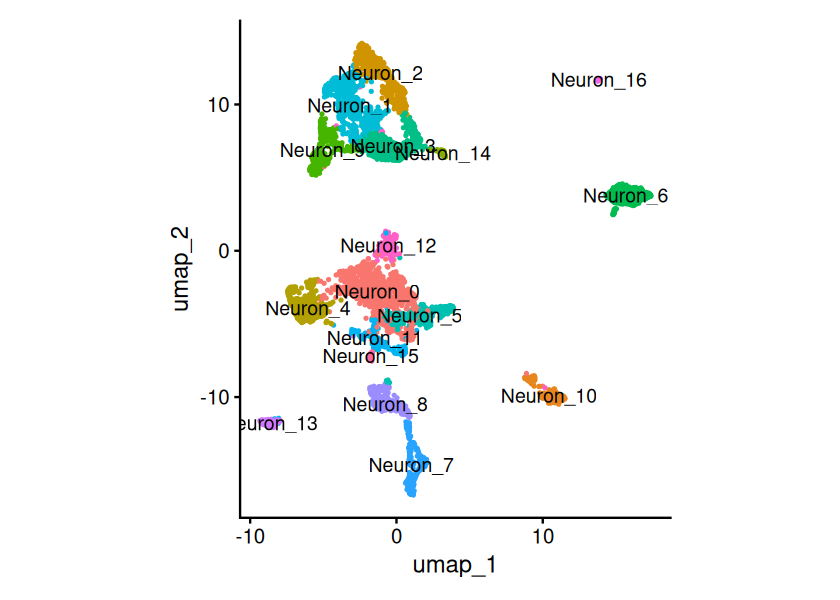

In [311]:
p_umap <- DimPlot(neuron_7, reduction = "umap", label = TRUE, raster = FALSE) +
    coord_fixed() +
    NoLegend()

options(repr.plot.width = 7, repr.plot.height = 5)
print(p_umap)

ggsave(
    filename = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_neuron_cluster_umap-new.pdf",
    plot = p_umap,
    width = 7,
    height = 5,
    units = "in",
    device = grDevices::cairo_pdf
)

character(0)


   0    1   10   11   12   13   14   15   16    2    3    4    5    6    7    8 
1096  556  228  211  195  118   58   43   35  505  500  458  373  359  312  310 
   9 
 298 

Warning message:
“'ncol' is ignored with 'stack' is TRUE”


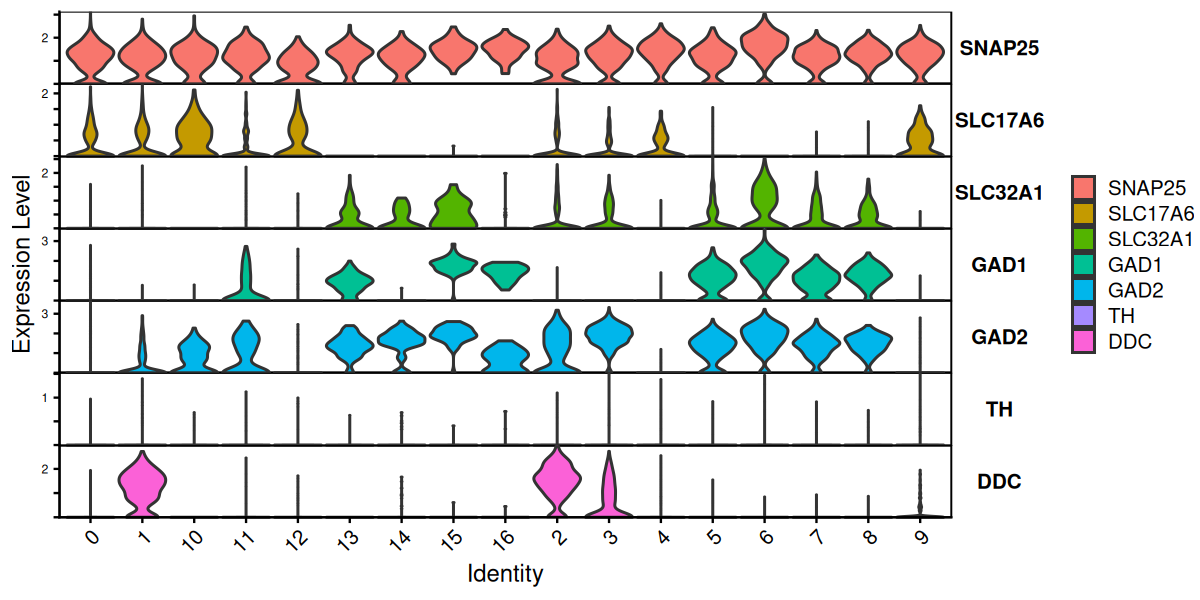

In [261]:
features_use = c("SNAP25","SLC17A6","SLC32A1", "GAD1", "GAD2", "TH", "DDC")

# 保留原始身份，不修改 merge_1
cluster_raw <- as.character(Idents(neuron_6))

# 按 Class 和 cluster 生成顺序
meta_plot <- neuron_6[[]] |>
    dplyr::transmute(
        Class = Class,
        cluster_raw = as.character(seurat_clusters)
    )

cluster_order <- meta_plot |>
    dplyr::distinct(Class, cluster_raw) |>
    dplyr::arrange(Class, cluster_raw) |>
    dplyr::pull(cluster_raw)

# 检查排序中的 cluster 是否覆盖全部实际 cluster
setdiff(unique(cluster_raw), cluster_order)

plot_obj <- neuron_6

plot_obj$cluster_plot <- factor(
    cluster_raw,
    levels = cluster_order
)

Idents(plot_obj) <- "cluster_plot"

table(plot_obj$cluster_plot, useNA = "ifany")

cell_count <- plot_obj[[]] |>
    dplyr::count(cluster_plot, name = "n")

p_vln <- VlnPlot(
    plot_obj,
    features = features_use,
    group.by = "cluster_plot",
    pt.size = 0,
    stack = TRUE,
    flip = TRUE,
    sort = FALSE,
    ncol = 1
)

print(p_vln)


 Neuron_0 Neuron_12  Neuron_4  Neuron_9  Neuron_1 Neuron_10 Neuron_11  Neuron_2 
     1096       195       458       298       556       228       211       505 
 Neuron_3 Neuron_13 Neuron_14 Neuron_15 Neuron_16  Neuron_5  Neuron_6  Neuron_7 
      500       118        58        43        35       373       359       312 
 Neuron_8 
      310 

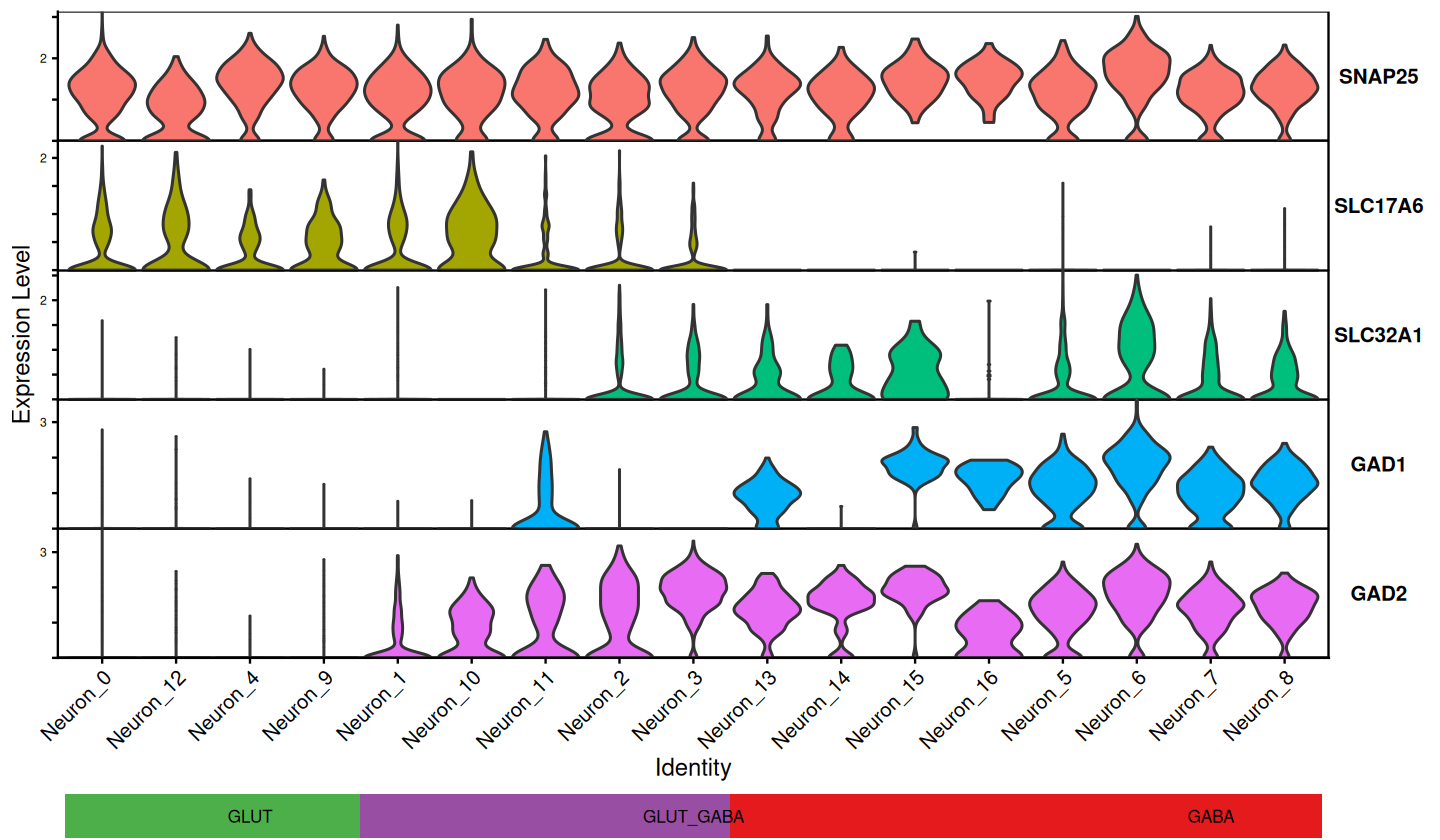

In [283]:
features_use = c("SNAP25", "SLC17A6", "SLC32A1", "GAD1", "GAD2")
GLUT = c('Neuron_0','Neuron_12','Neuron_4','Neuron_9')
GABA = c('Neuron_13','Neuron_14','Neuron_15','Neuron_16','Neuron_5','Neuron_6','Neuron_7','Neuron_8')
GLUT_GABA = c('Neuron_1','Neuron_10','Neuron_11','Neuron_2','Neuron_3')

Idents(neuron_7) <- "cluster"
cluster_raw <- as.character(Idents(neuron_7))

# 按归总类别排列 cluster；未归类的 cluster 放在最后
cluster_order <- c(
    intersect(GLUT, unique(cluster_raw)),
    intersect(GLUT_GABA, unique(cluster_raw)),
    intersect(GABA, unique(cluster_raw)),
    setdiff(unique(cluster_raw), c(GLUT, GLUT_GABA, GABA))
)

plot_obj <- neuron_7
plot_obj$cluster_plot <- factor(cluster_raw, levels = cluster_order)

plot_obj$cluster_class <- dplyr::case_when(
    plot_obj$cluster_plot %in% GLUT ~ "GLUT",
    plot_obj$cluster_plot %in% GLUT_GABA ~ "GLUT_GABA",
    plot_obj$cluster_plot %in% GABA ~ "GABA",
    TRUE ~ "Other"
)

plot_obj$cluster_class <- factor(
    plot_obj$cluster_class,
    levels = c("GLUT", "GLUT_GABA", "GABA", "Other")
)

Idents(plot_obj) <- "cluster_plot"

table(plot_obj$cluster_plot, useNA = "ifany")

p_vln <- VlnPlot(
    plot_obj,
    features = features_use,
    group.by = "cluster_plot",
    pt.size = 0,
    stack = TRUE,
    flip = TRUE,
    sort = FALSE
) +
    NoLegend()

cluster_bar_df <- plot_obj[[]] |>
    dplyr::count(cluster_class, name = "n_cells") |>
    dplyr::arrange(cluster_class) |>
    dplyr::mutate(
        x_end = cumsum(n_cells),
        x_start = dplyr::lag(x_end, default = 0),
        x_mid = (x_start + x_end) / 2
    )

p_class_bar <- ggplot(cluster_bar_df, aes(fill = cluster_class)) +
    geom_rect(aes(xmin = x_start, xmax = x_end, ymin = 0, ymax = 1)) +
    geom_text(
        aes(x = x_mid, y = 0.5, label = cluster_class),
        inherit.aes = FALSE,
        size = 3.5
    ) +
    scale_fill_manual(
        values = c(
            GLUT = "#4DAF4A",
            GLUT_GABA = "#984EA3",
            GABA = "#E41A1C",
            Other = "grey70"
        ),
        drop = FALSE
    ) +
    scale_x_continuous(
        limits = c(0, sum(cluster_bar_df$n_cells)),
        expand = c(0, 0)
    ) +
    theme_void() +
    theme(
        legend.position = "none",
        plot.margin = ggplot2::margin(0, 5.5, 0, 5.5)
    )

p_final <- cowplot::plot_grid(
    p_vln,
    p_class_bar,
    ncol = 1,
    align = "v",
    axis = "lr",
    rel_heights = c(1, 0.06)
)

options(repr.plot.width = 12, repr.plot.height = 7)
print(p_final)

ggsave(
    filename = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_neuron_marker_violin.pdf",
    plot = p_final,
    width = 12,
    height = 7,
    units = "in",
    device = grDevices::cairo_pdf
)

In [ ]:
GLUT = c('Neuron_0','Neuron_12','Neuron_4','Neuron_9')
GABA = c('Neuron_13','Neuron_14','Neuron_15','Neuron_16','Neuron_5','Neuron_6','Neuron_7','Neuron_8')
GLUT_GABA = c('Neuron_1','Neuron_10','Neuron_11','Neuron_2','Neuron_3')

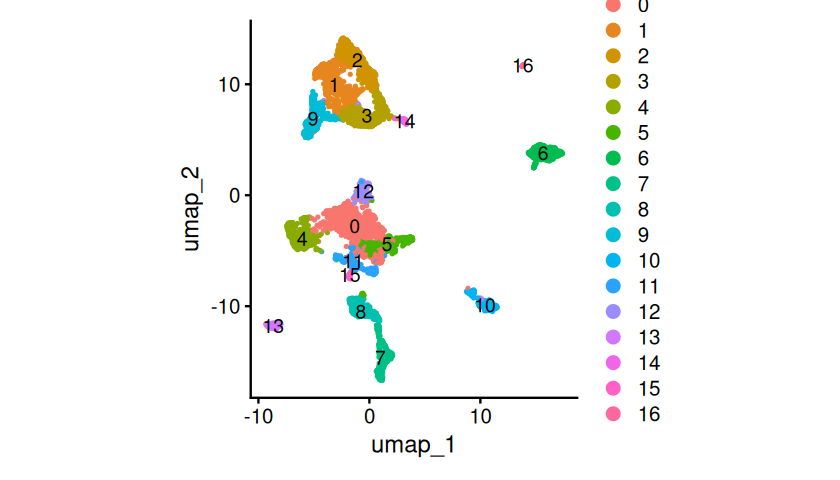

In [289]:

options(repr.plot.width=7, repr.plot.height=4)
Idents(neuron_7) <- 'seurat_clusters'
DimPlot(neuron_7, reduction="umap", label=T,raster=FALSE)+coord_fixed()

In [290]:
neuron_7$cluster = paste0("Neuron_", neuron_7$seurat_clusters)
table(neuron_7$cluster)


 Neuron_0  Neuron_1 Neuron_10 Neuron_11 Neuron_12 Neuron_13 Neuron_14 Neuron_15 
     1096       556       228       211       195       118        58        43 
Neuron_16  Neuron_2  Neuron_3  Neuron_4  Neuron_5  Neuron_6  Neuron_7  Neuron_8 
       35       505       500       458       373       359       312       310 
 Neuron_9 
      298 

In [333]:
neuron_8 = subset(neuron_7, !(cluster %in% c('Neuron_16')))
neuron_8

An object of class Seurat 
20344 features across 5620 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

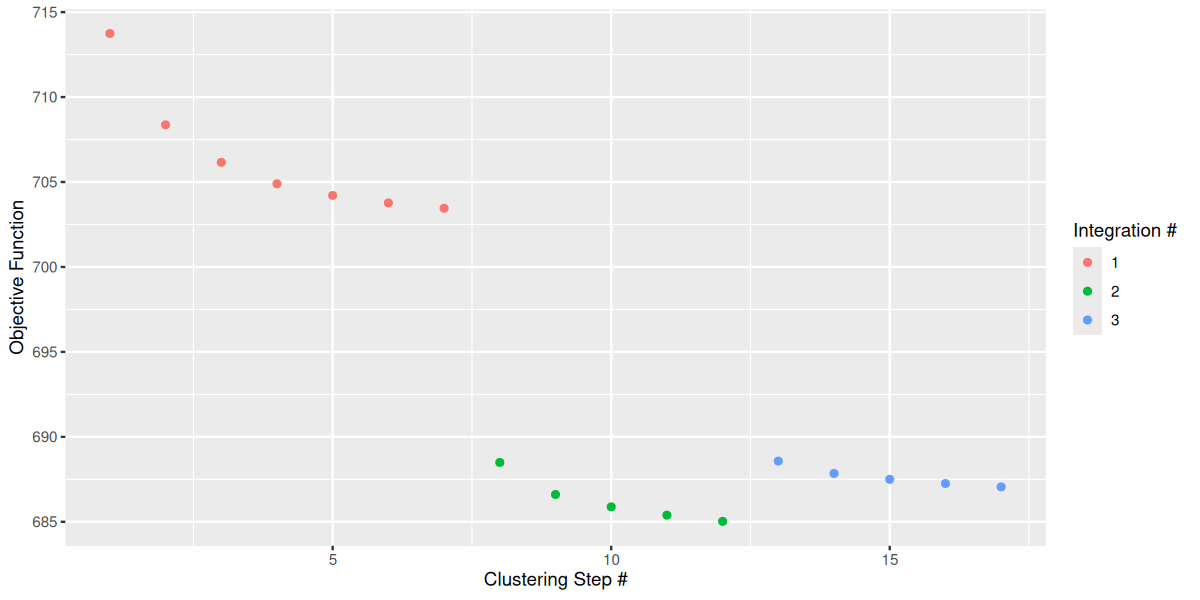

In [336]:
class_resolution = 0.3

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

assay = neuron_8@assays$RNA$counts
meta = neuron_8@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

neuron_9 = CreateSeuratObject(counts = new_assay)
neuron_9 = AddMetaData(neuron_9, meta)

neuron_9 = NormalizeData(neuron_9, normalization.method = "LogNormalize", scale.factor = 10000)
neuron_9 = FindVariableFeatures(neuron_9, selection.method = "vst", nfeatures = 3000)
neuron_9 = ScaleData(neuron_9, features = rownames(neuron_9))

neuron_9 = neuron_9 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:30) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:30, umap.method = "umap-learn")

neuron_9 = RunHarmony(
    neuron_9, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:30,
    theta = 2
)

neuron_9 = neuron_9 %>%
    FindNeighbors(reduction = "harmony", dims = 1:30) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:30)

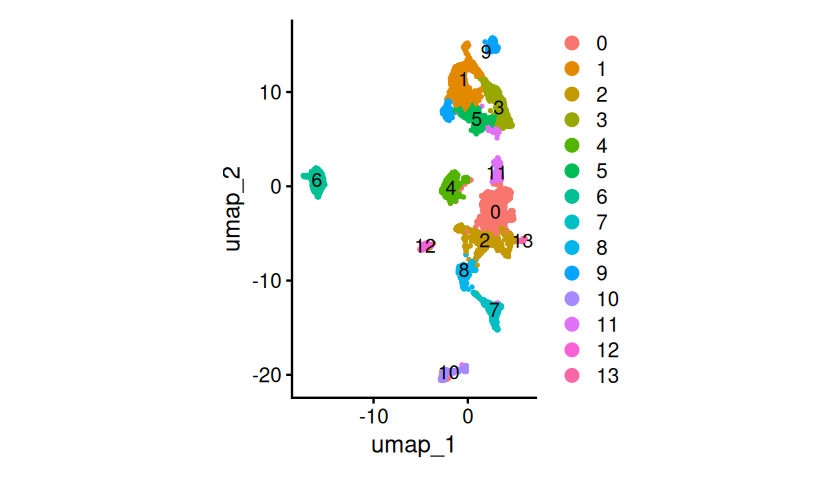

In [339]:

options(repr.plot.width=7, repr.plot.height=4)
Idents(neuron_9) <- 'seurat_clusters'
DimPlot(neuron_9, reduction="umap", label=T,raster=FALSE)+coord_fixed()


In [340]:
neuron_9$cluster = paste0("Neuron_", neuron_9$seurat_clusters)
table(neuron_9$cluster)


 Neuron_0  Neuron_1 Neuron_10 Neuron_11 Neuron_12 Neuron_13  Neuron_2  Neuron_3 
      965       758       228       197       118        43       722       503 
 Neuron_4  Neuron_5  Neuron_6  Neuron_7  Neuron_8  Neuron_9 
      459       369       359       313       310       276 

character(0)


 Neuron_0  Neuron_1 Neuron_10 Neuron_11 Neuron_12 Neuron_13  Neuron_2  Neuron_3 
      965       758       228       197       118        43       722       503 
 Neuron_4  Neuron_5  Neuron_6  Neuron_7  Neuron_8  Neuron_9 
      459       369       359       313       310       276 

Warning message:
“'ncol' is ignored with 'stack' is TRUE”


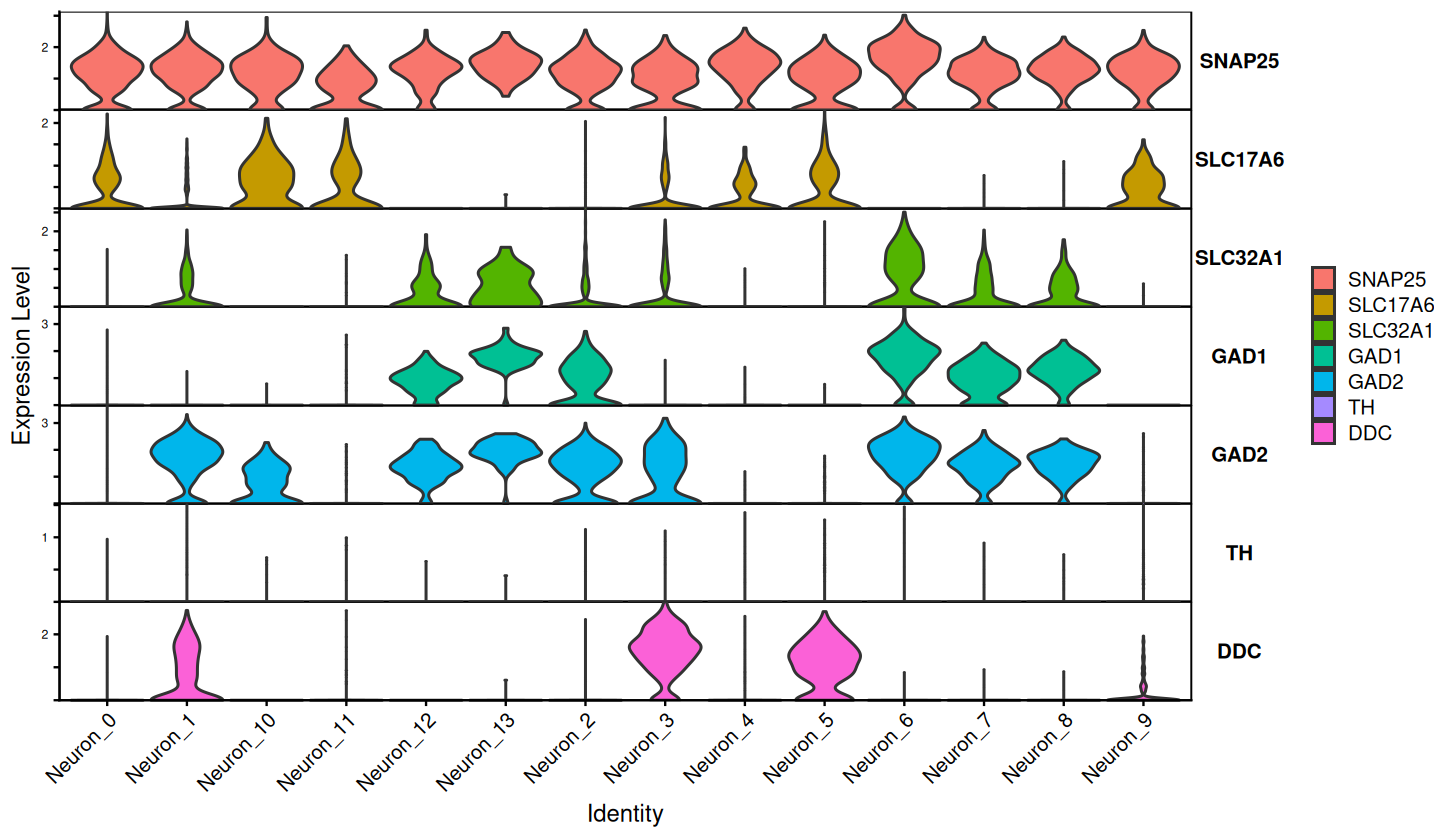

In [344]:
features_use = c("SNAP25","SLC17A6","SLC32A1", "GAD1", "GAD2", "TH", "DDC")

# 保留原始身份，不修改 merge_1
cluster_raw <- as.character(Idents(neuron_9))

# 按 Class 和 cluster 生成顺序
meta_plot <- neuron_9[[]] |>
    dplyr::transmute(
        Class = Class,
        cluster_raw = as.character(cluster)
    )

cluster_order <- meta_plot |>
    dplyr::distinct(Class, cluster_raw) |>
    dplyr::arrange(Class, cluster_raw) |>
    dplyr::pull(cluster_raw)

# 检查排序中的 cluster 是否覆盖全部实际 cluster
setdiff(unique(cluster_raw), cluster_order)

plot_obj <- neuron_9

plot_obj$cluster_plot <- factor(
    cluster_raw,
    levels = cluster_order
)

Idents(plot_obj) <- "cluster_plot"

table(plot_obj$cluster_plot, useNA = "ifany")

cell_count <- plot_obj[[]] |>
    dplyr::count(cluster_plot, name = "n")

p_vln <- VlnPlot(
    plot_obj,
    features = features_use,
    group.by = "cluster_plot",
    pt.size = 0,
    stack = TRUE,
    flip = TRUE,
    sort = FALSE,
    ncol = 1
)

print(p_vln)


 Neuron_0 Neuron_11  Neuron_4  Neuron_5  Neuron_9  Neuron_1 Neuron_10  Neuron_3 
      965       197       459       369       276       758       228       503 
Neuron_12 Neuron_13  Neuron_2  Neuron_6  Neuron_7  Neuron_8 
      118        43       722       359       313       310 

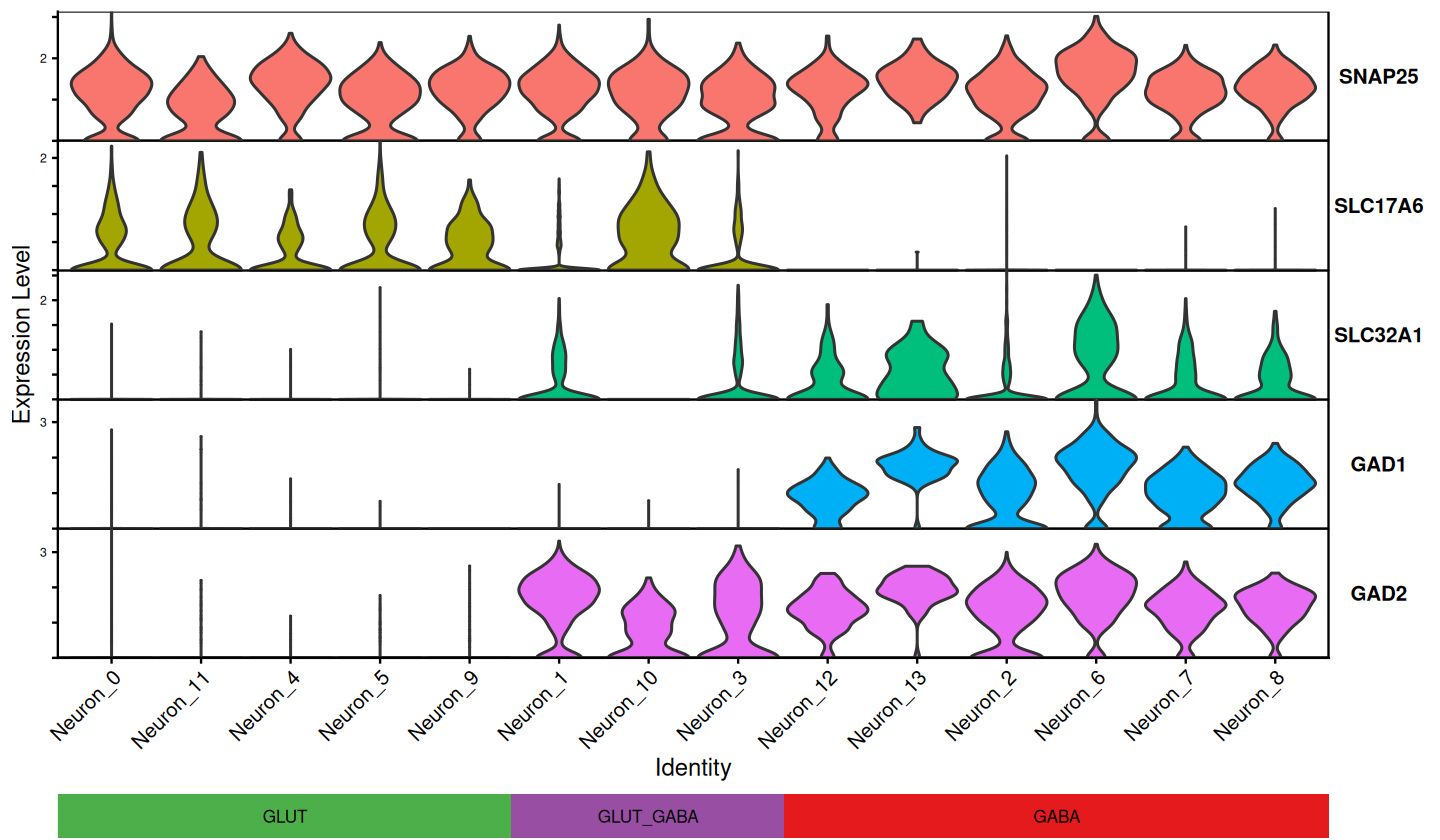

In [356]:
features_use = c("SNAP25", "SLC17A6", "SLC32A1", "GAD1", "GAD2")
GLUT = c('Neuron_0','Neuron_11','Neuron_4','Neuron_5','Neuron_9')
GABA = c('Neuron_12','Neuron_13','Neuron_2','Neuron_6','Neuron_7','Neuron_8')
GLUT_GABA = c('Neuron_1','Neuron_10','Neuron_3')

Idents(neuron_9) <- "cluster"
cluster_raw <- as.character(Idents(neuron_9))

# 按归总类别排列 cluster；未归类的 cluster 放在最后
cluster_order <- c(
    intersect(GLUT, unique(cluster_raw)),
    intersect(GLUT_GABA, unique(cluster_raw)),
    intersect(GABA, unique(cluster_raw)),
    setdiff(unique(cluster_raw), c(GLUT, GLUT_GABA, GABA))
)

plot_obj <- neuron_9
plot_obj$cluster_plot <- factor(cluster_raw, levels = cluster_order)

plot_obj$cluster_class <- dplyr::case_when(
    plot_obj$cluster_plot %in% GLUT ~ "GLUT",
    plot_obj$cluster_plot %in% GLUT_GABA ~ "GLUT_GABA",
    plot_obj$cluster_plot %in% GABA ~ "GABA",
    TRUE ~ "Other"
)

plot_obj$cluster_class <- factor(
    plot_obj$cluster_class,
    levels = c("GLUT", "GLUT_GABA", "GABA", "Other")
)

Idents(plot_obj) <- "cluster_plot"

table(plot_obj$cluster_plot, useNA = "ifany")

p_vln <- VlnPlot(
    plot_obj,
    features = features_use,
    group.by = "cluster_plot",
    pt.size = 0,
    stack = TRUE,
    flip = TRUE,
    sort = FALSE
) +
    NoLegend()

cluster_bar_df <- plot_obj[[]] |>
    dplyr::distinct(cluster_plot, cluster_class) |>
    dplyr::count(cluster_class, name = "n_clusters") |>
    dplyr::arrange(cluster_class) |>
    dplyr::mutate(
        x_end = cumsum(n_clusters),
        x_start = dplyr::lag(x_end, default = 0),
        x_mid = (x_start + x_end) / 2
    )

p_class_bar <- ggplot(cluster_bar_df, aes(fill = cluster_class)) +
    geom_rect(aes(xmin = x_start, xmax = x_end, ymin = 0, ymax = 1)) +
    geom_text(
        data = cluster_bar_df,
        aes(x = x_mid, y = 0.5, label = cluster_class),
        inherit.aes = FALSE,
        size = 3.5
    ) +
    scale_fill_manual(
        values = c(
            GLUT = "#4DAF4A",
            GLUT_GABA = "#984EA3",
            GABA = "#E41A1C",
            Other = "grey70"
        ),
        drop = FALSE
    ) +
    scale_x_continuous(
        limits = c(0, sum(cluster_bar_df$n_clusters)),
        expand = c(0, 0)
    ) +
    theme_void() +
    theme(
        legend.position = "none",
        plot.margin = ggplot2::margin(0, 5.5, 0, 5.5)
    )

p_final <- cowplot::plot_grid(
    p_vln,
    p_class_bar,
    ncol = 1,
    align = "v",
    axis = "lr",
    rel_heights = c(1, 0.06)
)

options(repr.plot.width = 12, repr.plot.height = 7)
print(p_final)

ggsave(
    filename = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_neuron_marker_violin-new.pdf",
    plot = p_final,
    width = 12,
    height = 7,
    units = "in",
    device = grDevices::cairo_pdf
)

In [387]:
neuron_11 = neuron_9

In [388]:
GLUT <- c('Neuron_0', 'Neuron_11', 'Neuron_4', 'Neuron_5', 'Neuron_9')
GABA <- c('Neuron_12', 'Neuron_13', 'Neuron_2', 'Neuron_6', 'Neuron_7', 'Neuron_8')
GLUT_GABA <- c('Neuron_1', 'Neuron_10', 'Neuron_3')

cluster_to_subclass <- c(
    stats::setNames(rep('GLUT', length(GLUT)), GLUT),
    stats::setNames(rep('GABA', length(GABA)), GABA),
    stats::setNames(rep('GLUT_GABA', length(GLUT_GABA)), GLUT_GABA)
)

neuron_clusters <- as.character(neuron_11$cluster)
if (!all(neuron_clusters %in% names(cluster_to_subclass))) {
    missing_clusters <- setdiff(unique(neuron_clusters), names(cluster_to_subclass))
    stop(paste('未定义 subclass 的 neuron cluster:', paste(missing_clusters, collapse = ', ')))
}
neuron_11$subclass <- unname(cluster_to_subclass[neuron_clusters])

table(neuron_11$cluster, neuron_11$subclass)

           
            GABA GLUT GLUT_GABA
  Neuron_0     0  965         0
  Neuron_1     0    0       758
  Neuron_10    0    0       228
  Neuron_11    0  197         0
  Neuron_12  118    0         0
  Neuron_13   43    0         0
  Neuron_2   722    0         0
  Neuron_3     0    0       503
  Neuron_4     0  459         0
  Neuron_5     0  369         0
  Neuron_6   359    0         0
  Neuron_7   313    0         0
  Neuron_8   310    0         0
  Neuron_9     0  276         0

In [389]:
original_neuron_clusters <- as.character(neuron_11$cluster)
if (anyNA(neuron_11$subclass)) {
    stop('neuron_11$subclass 包含缺失值；请先完成 subclass 定义。')
}

# 保留原始 cluster 编号，使同一 subclass 内的不同 cluster 仍可区分。
neuron_11$cluster <- paste0(
    neuron_11$subclass,
    '_',
    sub('^Neuron_', '', original_neuron_clusters)
 )

table(original_neuron_clusters, neuron_11$cluster)

                        
original_neuron_clusters GABA_12 GABA_13 GABA_2 GABA_6 GABA_7 GABA_8 GLUT_0
               Neuron_0        0       0      0      0      0      0    965
               Neuron_1        0       0      0      0      0      0      0
               Neuron_10       0       0      0      0      0      0      0
               Neuron_11       0       0      0      0      0      0      0
               Neuron_12     118       0      0      0      0      0      0
               Neuron_13       0      43      0      0      0      0      0
               Neuron_2        0       0    722      0      0      0      0
               Neuron_3        0       0      0      0      0      0      0
               Neuron_4        0       0      0      0      0      0      0
               Neuron_5        0       0      0      0      0      0      0
               Neuron_6        0       0      0    359      0      0      0
               Neuron_7        0       0      0      0    313  


      GLUT_0      GLUT_11       GLUT_4       GLUT_5       GLUT_9  GLUT_GABA_1 
         965          197          459          369          276          758 
GLUT_GABA_10  GLUT_GABA_3      GABA_12      GABA_13       GABA_2       GABA_6 
         228          503          118           43          722          359 
      GABA_7       GABA_8 
         313          310 

ERROR: Error in ggsave(plot = p_final, width = 11, height = 7, units = "in", : 缺少参数"filename",也缺失默认值


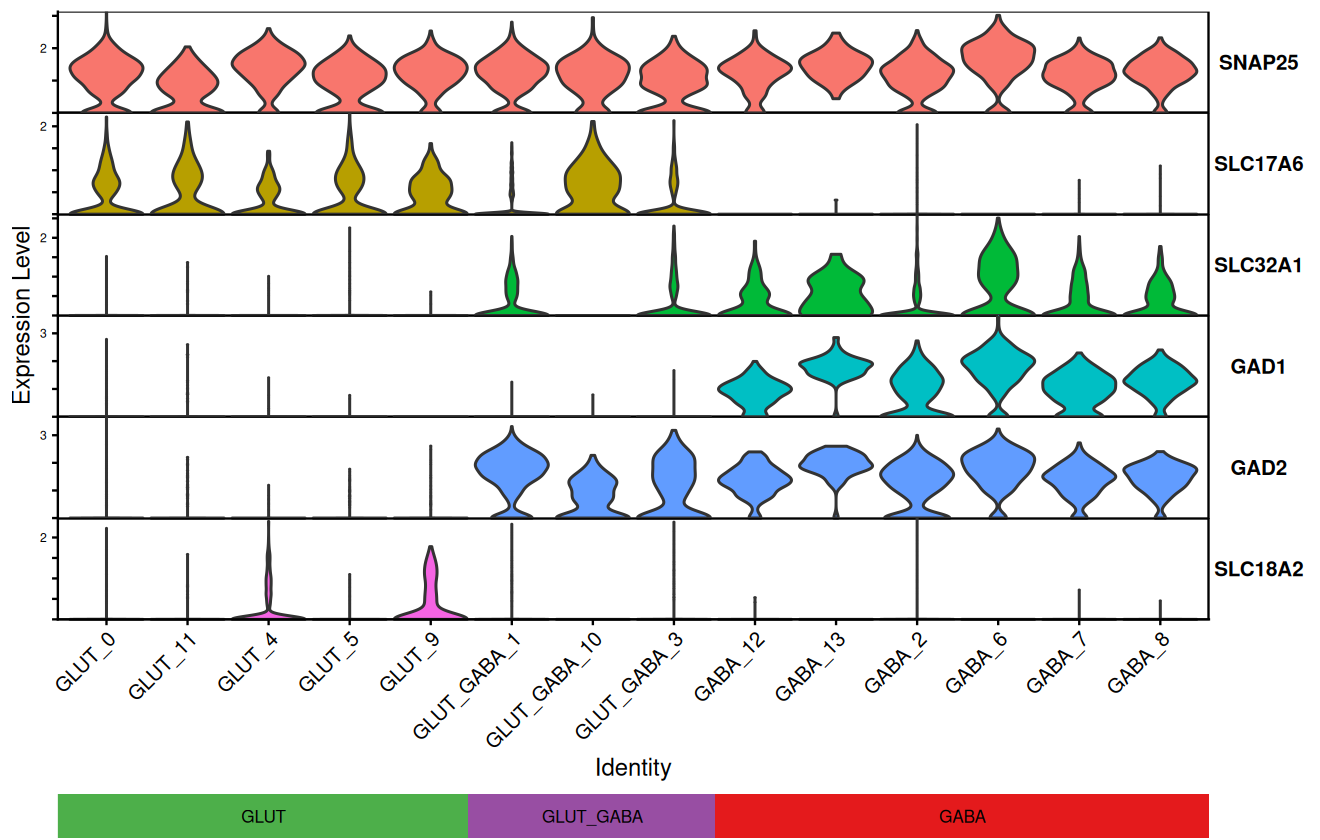

In [ ]:
features_use = c("SNAP25", "SLC17A6", "SLC32A1", "GAD1", "GAD2","SLC18A2")
GLUT = c('GLUT_0','GLUT_11','GLUT_4','GLUT_5','GLUT_9')
GABA = c('GABA_12','GABA_13','GABA_2','GABA_6','GABA_7','GABA_8')
GLUT_GABA = c('GLUT_GABA_1','GLUT_GABA_10','GLUT_GABA_3')

Idents(neuron_11) <- "cluster"
cluster_raw <- as.character(Idents(neuron_11))

# 按归总类别排列 cluster；未归类的 cluster 放在最后
cluster_order <- c(
    intersect(GLUT, unique(cluster_raw)),
    intersect(GLUT_GABA, unique(cluster_raw)),
    intersect(GABA, unique(cluster_raw)),
    setdiff(unique(cluster_raw), c(GLUT, GLUT_GABA, GABA))
)

plot_obj <- neuron_11
plot_obj$cluster_plot <- factor(cluster_raw, levels = cluster_order)

plot_obj$cluster_class <- dplyr::case_when(
    plot_obj$cluster_plot %in% GLUT ~ "GLUT",
    plot_obj$cluster_plot %in% GLUT_GABA ~ "GLUT_GABA",
    plot_obj$cluster_plot %in% GABA ~ "GABA",
    TRUE ~ "Other"
)

plot_obj$cluster_class <- factor(
    plot_obj$cluster_class,
    levels = c("GLUT", "GLUT_GABA", "GABA", "Other")
)

Idents(plot_obj) <- "cluster_plot"

table(plot_obj$cluster_plot, useNA = "ifany")

p_vln <- VlnPlot(
    plot_obj,
    features = features_use,
    group.by = "cluster_plot",
    pt.size = 0,
    stack = TRUE,
    flip = TRUE,
    sort = FALSE
) +
    NoLegend()

cluster_bar_df <- plot_obj[[]] |>
    dplyr::distinct(cluster_plot, cluster_class) |>
    dplyr::count(cluster_class, name = "n_clusters") |>
    dplyr::arrange(cluster_class) |>
    dplyr::mutate(
        x_end = cumsum(n_clusters),
        x_start = dplyr::lag(x_end, default = 0),
        x_mid = (x_start + x_end) / 2
    )

p_class_bar <- ggplot(cluster_bar_df, aes(fill = cluster_class)) +
    geom_rect(aes(xmin = x_start, xmax = x_end, ymin = 0, ymax = 1)) +
    geom_text(
        data = cluster_bar_df,
        aes(x = x_mid, y = 0.5, label = cluster_class),
        inherit.aes = FALSE,
        size = 3.5
    ) +
    scale_fill_manual(
        values = c(
            GLUT = "#4DAF4A",
            GLUT_GABA = "#984EA3",
            GABA = "#E41A1C",
            Other = "grey70"
        ),
        drop = FALSE
    ) +
    scale_x_continuous(
        limits = c(0, sum(cluster_bar_df$n_clusters)),
        expand = c(0, 0)
    ) +
    theme_void() +
    theme(
        legend.position = "none",
        plot.margin = ggplot2::margin(0, 5.5, 0, 5.5)
    )

p_final <- cowplot::plot_grid(
    p_vln,
    p_class_bar,
    ncol = 1,
    align = "v",
    axis = "lr",
    rel_heights = c(1, 0.06)
)

options(repr.plot.width = 11, repr.plot.height = 7)
print(p_final)


In [419]:

ggsave(
    filename = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_neuron_marker_violin-new-2.pdf",
    plot = p_final,
    width = 11,
    height = 7,
    units = "in",
    device = grDevices::cairo_pdf
)

In [397]:
pdf(file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_neuron_cluster_umap-new.pdf", width = 8, height = 8)

options(repr.plot.width=8, repr.plot.height=8)
Idents(neuron_11) <- 'cluster'
DimPlot(neuron_11, reduction="umap", label=T,raster=FALSE)+coord_fixed()

dev.off()

agg_record_1472487104 
                    2

In [423]:
saveRDS(neuron_11, '/mnt/90-connectome/Personal/CQW/midbrain/datasets/20260831_VTA_Neuron_cluster.rds')

In [403]:
sampleRatio = 0.8
maxCell = 200
sampleDf = neuron_11@meta.data[, c("cluster"), drop=F]
sampleList = split(sampleDf, sampleDf$cluster)
sampleList = lapply(sampleList, function(x) {
    sampleSize = as.integer(nrow(x)*0.8)
    if (sampleSize > maxCell) {
        sampleSize = maxCell
    }
    sampleIdx = 1:nrow(x)
    sampleIdx = sample(1:nrow(x), size=sampleSize, replace=F)
    return(x[sampleIdx,,drop=F])
})
sampleDf = Reduce(rbind, sampleList)
str(sampleDf)
table(sampleDf$cluster)

trainSeurat = neuron_11[,rownames(sampleDf)]
table(trainSeurat$cluster)

'data.frame':	2467 obs. of  1 variable:
 $ cluster: chr  "GABA_12" "GABA_12" "GABA_12" "GABA_12" ...



     GABA_12      GABA_13       GABA_2       GABA_6       GABA_7       GABA_8 
          94           34          200          200          200          200 
      GLUT_0      GLUT_11       GLUT_4       GLUT_5       GLUT_9  GLUT_GABA_1 
         200          157          200          200          200          200 
GLUT_GABA_10  GLUT_GABA_3 
         182          200 


     GABA_12      GABA_13       GABA_2       GABA_6       GABA_7       GABA_8 
          94           34          200          200          200          200 
      GLUT_0      GLUT_11       GLUT_4       GLUT_5       GLUT_9  GLUT_GABA_1 
         200          157          200          200          200          200 
GLUT_GABA_10  GLUT_GABA_3 
         182          200 

In [404]:
Idents(trainSeurat) = "cluster"
classMarker = FindAllMarkers(trainSeurat)
classMarker = subset(classMarker, p_val_adj < 0.01 & avg_log2FC > 1.0)
table(classMarker$cluster)

# classMarkerTop = classMarker %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)
# options(repr.plot.width=length(unique(classMarkerTop$gene))/3, repr.plot.height=8)
# Idents(neuron_7) = "cluster"
# DotPlot(neuron_7, features=unique(c(classMarkerTop$gene))) + RotatedAxis()

Calculating cluster GLUT_GABA_10



Calculating cluster GLUT_0

Calculating cluster GLUT_4

Calculating cluster GLUT_GABA_3

Calculating cluster GLUT_GABA_1

Calculating cluster GABA_6

Calculating cluster GLUT_9

Calculating cluster GLUT_5

Calculating cluster GABA_8

Calculating cluster GABA_7

Calculating cluster GABA_12

Calculating cluster GLUT_11

Calculating cluster GABA_2

Calculating cluster GABA_13




GLUT_GABA_10       GLUT_0       GLUT_4  GLUT_GABA_3  GLUT_GABA_1       GABA_6 
         333           86          210          119           83          478 
      GLUT_9       GLUT_5       GABA_8       GABA_7      GABA_12      GLUT_11 
         229          106          272          241          454          216 
      GABA_2      GABA_13 
          57          343 

In [405]:
trainDf = as.data.frame(t(as.matrix(trainSeurat[["RNA"]]$data[unique(classMarker$gene), ])))
trainDf$cluster = trainSeurat$cluster
trainDf = subset(trainDf, cluster != "Uncertain")
trainDf$cluster = factor(trainDf$cluster)
# We need to modify the name of the columns
colnames(trainDf) = paste0("col_", colnames(trainDf))
colnames(trainDf) = gsub("-", "_", colnames(trainDf))
colnames(trainDf) = gsub(" ", "_", colnames(trainDf))

rf = randomForest(col_cluster~., data=trainDf, ntree=300)

 num [1:14, 1:15] 94 0 0 0 0 0 0 0 0 0 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:14] "GABA_12" "GABA_13" "GABA_2" "GABA_6" ...
  ..$ : chr [1:15] "GABA_12" "GABA_13" "GABA_2" "GABA_6" ...


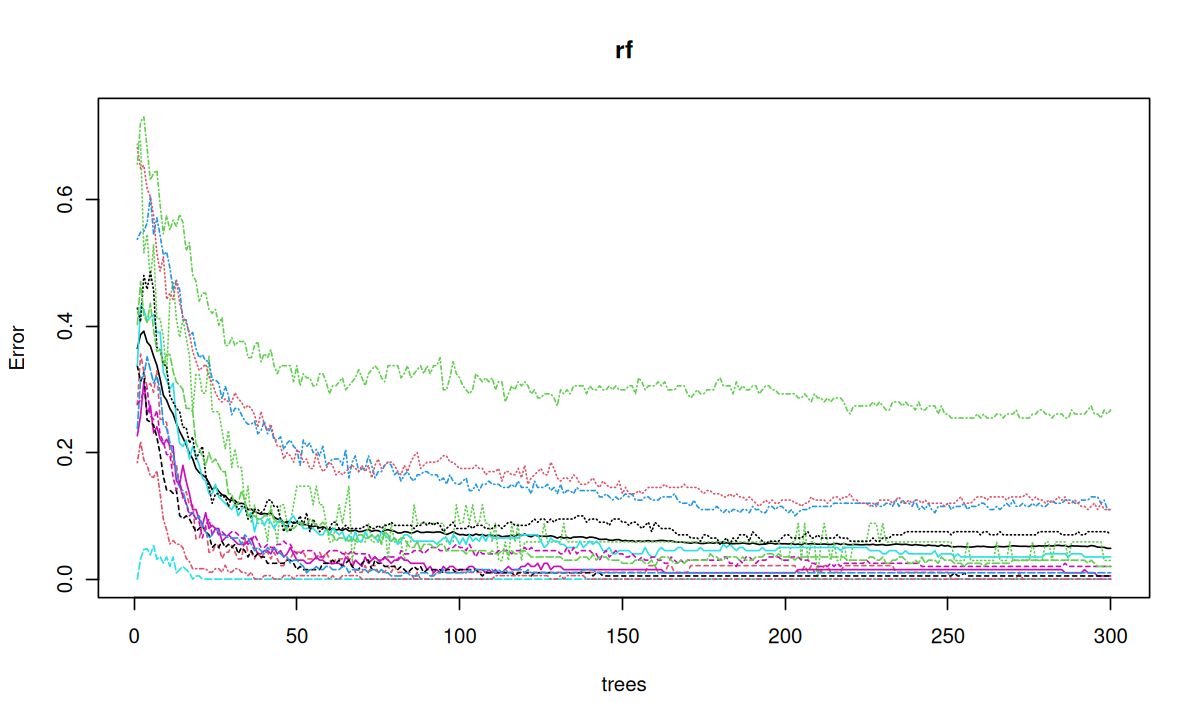

In [406]:
str(rf$confusion)
options(repr.plot.width=10, repr.plot.height=6)
plot(rf)

In [409]:
confusionRatio = t(apply(rf$confusion[1:14, 1:14], 1, function(x) x / sum(x)))

display_values <- ifelse(confusionRatio > 0.5, sprintf("%.2f", confusionRatio), "")

options(repr.plot.width = 8, repr.plot.height = 8)
pheatmap(
    confusionRatio,
    breaks = seq(0, 1, 0.01),
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    border_color = NA,
    cellwidth = 25,
    cellheight = 25,
    fontsize = 15,
    display_numbers = display_values,
    file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_neuron_randomForest_confusion-new-1.pdf"
)

In [417]:
table(neuron_11$cluster)


      GLUT_0       GLUT_4       GLUT_5       GLUT_9      GLUT_11  GLUT_GABA_1 
         965          459          369          276          197          758 
 GLUT_GABA_3 GLUT_GABA_10       GABA_2       GABA_6       GABA_7       GABA_8 
         503          228          722          359          313          310 
     GABA_12      GABA_13 
         118           43 

In [410]:
Idents(neuron_11) <- 'cluster'
neuron_11_sub  = subset(neuron_11, downsample = 200)
marker = FindAllMarkers(neuron_11_sub, only.pos = TRUE, test.use = "MAST")


Calculating cluster GABA_2


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster GLUT_GABA_10


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster GLUT_0


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster GLUT_GABA_3


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster GLUT_4


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster GLUT_GABA_1


Done!

Combining coefficients 

In [422]:
write.csv(
    marker,
    "/mnt/90-connectome/Personal/CQW/midbrain/datasets/Neuron_cluster_markers.csv",
    row.names = TRUE
)

In [411]:
markers_filt = marker

MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
markers_filt <- markers_filt[!markers_filt$gene %in% MTGenes, ]
markers_filt = markers_filt %>% filter(!grepl("^ENSMFAG", gene))

markers_filt = subset(markers_filt, p_val_adj < 0.01)
markers_filt = subset(markers_filt, avg_log2FC > 0.5)

table(markers_filt$cluster)


      GABA_2 GLUT_GABA_10       GLUT_0  GLUT_GABA_3       GLUT_4  GLUT_GABA_1 
          83          452          200          369          321          155 
      GABA_6       GLUT_9       GLUT_5       GABA_7       GABA_8      GABA_12 
        1491          594          292          352          527          588 
     GLUT_11      GABA_13 
         434          370 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


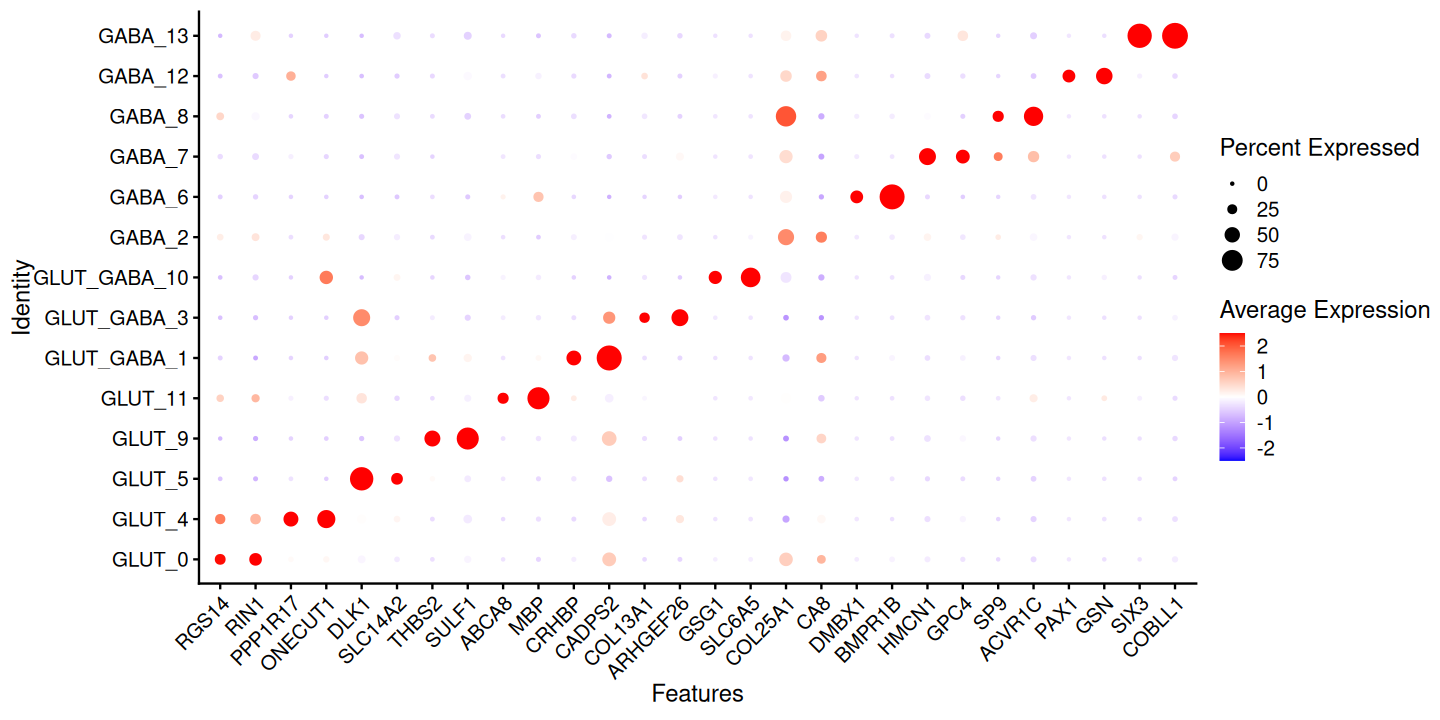

In [415]:
# 按 subclass 聚集 cluster；同一 subclass 内按原始 cluster 编号排序。
subclass_order <- c("GLUT", "GLUT_GABA", "GABA")
cluster_order <- neuron_11[[]] |>
    dplyr::distinct(cluster, subclass) |>
    dplyr::mutate(
        subclass = factor(subclass, levels = subclass_order),
        cluster_number = as.integer(sub("^.*_", "", cluster))
    ) |>
    dplyr::arrange(subclass, cluster_number) |>
    dplyr::pull(cluster)

# 每个 cluster 选择 pct.1 > 0.3 且 avg_log2FC 最高的 2 个基因。
# 基因块与 cluster_order 对齐，使 marker 在 DotPlot 中沿对角线排列。
markers_filt_top2 <- markers_filt |>
    dplyr::filter(pct.1 > 0.3) |>
    dplyr::mutate(cluster = factor(cluster, levels = cluster_order)) |>
    dplyr::group_by(cluster) |>
    dplyr::arrange(dplyr::desc(avg_log2FC), .by_group = TRUE) |>
    dplyr::slice_head(n = 2) |>
    dplyr::ungroup()

gene_order <- markers_filt_top2 |>
    dplyr::arrange(cluster, dplyr::desc(avg_log2FC)) |>
    dplyr::pull(gene) |>
    unique()

neuron_11$cluster <- factor(neuron_11$cluster, levels = cluster_order)

options(repr.plot.width = 12, repr.plot.height = 6)
DotPlot(neuron_11, features = gene_order, dot.scale = 6, group.by = "cluster") +
    RotatedAxis(45) +
    theme(
        axis.text.y = element_text(size = 12),
        axis.text.x = element_text(size = 12)
    ) +
    scale_color_gradient2(
        low = "blue", mid = "white", high = "red",
        midpoint = 0, limits = c(-2.5, 2.5)
    )

In [416]:
pdf(file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_neuron_cluster_marker_dotplot-new.pdf", width = 12, height = 6)

options(repr.plot.width = 12, repr.plot.height = 6)
DotPlot(neuron_11, features = gene_order, dot.scale = 6, group.by = "cluster") +
    RotatedAxis(45) +
    theme(
        axis.text.y = element_text(size = 12),
        axis.text.x = element_text(size = 12)
    ) +
    scale_color_gradient2(
        low = "blue", mid = "white", high = "red",
        midpoint = 0, limits = c(-2.5, 2.5)
    )

dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


agg_record_651436069 
                   2